In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
import kagglehub

path = kagglehub.dataset_download("aryayadav0513/m5-forecasting-accuracy")
print("Path:", path)

100%|██████████| 45.8M/45.8M [00:01<00:00, 27.8MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/aryayadav0513/m5-forecasting-accuracy/versions/1


In [ ]:
import os

os.listdir(path)

['m5-forecasting-accuracy']

In [ ]:
import os

os.listdir(path)

['m5-forecasting-accuracy']

In [ ]:
sales = pd.read_csv(f"{path}/m5-forecasting-accuracy/sales_train_validation.csv")
calendar = pd.read_csv(f"{path}/m5-forecasting-accuracy/calendar.csv")
prices = pd.read_csv(f"{path}/m5-forecasting-accuracy/sell_prices.csv")

In [ ]:
import os

dataset_path = os.path.join(path, "m5-forecasting-accuracy")

sales = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(dataset_path, "calendar.csv"))
prices = pd.read_csv(os.path.join(dataset_path, "sell_prices.csv"))

In [ ]:
print(sales.shape)
print(calendar.shape)
print(prices.shape)

(30490, 1919)
(1969, 14)
(6841121, 4)


In [ ]:
print(path)
os.listdir(path)

/root/.cache/kagglehub/datasets/aryayadav0513/m5-forecasting-accuracy/versions/1


['m5-forecasting-accuracy']

In [ ]:
sales = pd.read_csv(os.path.join(dataset_path, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(dataset_path, "calendar.csv"))
prices = pd.read_csv(os.path.join(dataset_path, "sell_prices.csv"))

In [ ]:
# FILTER STATE DAN CATEGORY
sales = sales[
    (sales['state_id'].isin(['CA','TX','WI'])) &
    (sales['cat_id'].isin(['HOBBIES','HOUSEHOLD','FOODS']))
]

# AMBIL 50% PRODUCT
sales = sales.sample(frac=0.5, random_state=42)

# AMBIL 50% DAYS
day_cols = [c for c in sales.columns if 'd_' in c]
half_days = day_cols[:len(day_cols)//2]

sales = sales[['item_id','dept_id','cat_id','store_id','state_id'] + half_days]

In [ ]:
sales_long = sales.melt(
    id_vars=['item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)

In [ ]:
sales_long = sales_long.merge(
    calendar[['d','wm_yr_wk']],
    on='d',
    how='left'
)

In [ ]:
sales_long = sales_long.merge(
    prices,
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

In [ ]:
sales_long['revenue'] = sales_long['sales'] * sales_long['sell_price']

In [ ]:
weekly_avg = sales_long.groupby(
    ['cat_id','state_id','wm_yr_wk']
)['revenue'].sum().reset_index()

In [ ]:
del sales_long
import gc
gc.collect()

37

In [ ]:
hobbies = weekly_avg[weekly_avg['cat_id']=='HOBBIES']
household = weekly_avg[weekly_avg['cat_id']=='HOUSEHOLD']
foods = weekly_avg[weekly_avg['cat_id']=='FOODS']

### Baseline Models: Seasonal Naive & Simple Exponential Smoothing

This section implements two classical **baseline** forecasting methods, used as a lower-bar sanity check against which ARIMA / Random Forest / XGBoost / LightGBM / CNN are compared:

- **Seasonal Naive**: forecasts each week as the value observed `season_length` weeks ago (falls back to the last observed value whenever there isn't enough history yet, e.g. at the very start of the walk-forward window).
- **Simple Exponential Smoothing (SES)**: a weighted average of past observations with exponentially decaying weights (no trend/seasonality component), refit at every step of the walk-forward loop.

**Key steps:**
1. **Walk-forward prediction** — identical protocol to the other sections: derive/fit on history, forecast one week ahead, then append the actual observed test value to history before moving to the next week.
2. **Metrics** — MAE, RMSE, RMSSE, WRMSEE, and MAPE, computed with the same helper functions used elsewhere in the notebook.
3. **Visualization** — real vs. Seasonal Naive vs. SES weekly revenue, one chart pair per category, one line pair per state.


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ==========================================================
# METRICS (identical to the ARIMA / RandomForest / XGBoost / LightGBM sections)
# ==========================================================

def calculate_rmsse(train, test, forecast):
    train = np.array(train).flatten()
    test = np.array(test).flatten()
    forecast = np.array(forecast).flatten()

    denominator = np.mean(np.diff(train) ** 2)
    if denominator < 1e-8:
        return np.nan

    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)

def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Drop the incomplete final boundary week (same as ARIMA section) ---
last_week = weekly_avg['wm_yr_wk'].max()
weekly_avg_filtered = weekly_avg[weekly_avg['wm_yr_wk'] != last_week].copy()

categories = ['HOBBIES', 'HOUSEHOLD', 'FOODS']
states = ['CA', 'TX', 'WI']
test_size = 30
lookback = 10        # Aligns index with the RNN lookback window
season_length = 52   # Weekly data -> yearly seasonality; falls back to naive if history is short

# Pre-calculate absolute revenue weights for WRMSEE scaling
revenue_weights = {}
grand_total_revenue = 0

for cat in categories:
    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ]
        if not df_subset.empty:
            total_rev = df_subset['revenue'].sum()
            revenue_weights[(cat, state)] = total_rev
            grand_total_revenue += total_rev

# Plot aesthetics
colors_real = {'CA': 'tab:blue', 'TX': 'tab:green', 'WI': 'tab:purple'}
colors_snaive = {'CA': 'tab:orange', 'TX': 'tab:red', 'WI': 'tab:brown'}
colors_ses = {'CA': 'gold', 'TX': 'deeppink', 'WI': 'slategray'}

baseline_results = []  # collect per-series metrics for both baselines

for cat in categories:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    print("=" * 60)
    print(f" CATEGORY: {cat} ")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ].sort_values('wm_yr_wk')

        series = df_subset['revenue'].values
        if len(series) == 0:
            continue

        train = series[:-test_size]
        test = series[-test_size:]

        weight = revenue_weights.get((cat, state), 0) / grand_total_revenue

        # ------------------------------------------------------------
        # 1. SEASONAL NAIVE - walk-forward
        # ------------------------------------------------------------
        history = list(train)
        snaive_preds = []
        for t in range(len(test)):
            if len(history) >= season_length:
                yhat = history[-season_length]
            else:
                yhat = history[-1]   # not enough history yet -> plain naive fallback
            snaive_preds.append(yhat)
            history.append(test[t])
        snaive_preds = np.array(snaive_preds)

        # In-sample fitted values for the plot (same fallback logic)
        snaive_in_sample = np.array([
            train[i - season_length] if i >= season_length else (train[i - 1] if i >= 1 else train[0])
            for i in range(len(train))
        ])
        snaive_full_pred = np.concatenate([snaive_in_sample, snaive_preds])

        # ------------------------------------------------------------
        # 2. SIMPLE EXPONENTIAL SMOOTHING - walk-forward (refit each step)
        # ------------------------------------------------------------
        history = list(train)
        ses_preds = []
        for t in range(len(test)):
            ses_model = SimpleExpSmoothing(history, initialization_method="estimated").fit(optimized=True)
            yhat = ses_model.forecast(1)[0]
            ses_preds.append(yhat)
            history.append(test[t])
        ses_preds = np.array(ses_preds)

        ses_initial = SimpleExpSmoothing(train, initialization_method="estimated").fit(optimized=True)
        ses_in_sample = ses_initial.fittedvalues
        ses_full_pred = np.concatenate([ses_in_sample, ses_preds])

        # ------------------------------------------------------------
        # Metrics for both models
        # ------------------------------------------------------------
        for name, preds in [("Seasonal Naive", snaive_preds), ("SES", ses_preds)]:
            mae = mean_absolute_error(test, preds)
            rmse = np.sqrt(mean_squared_error(test, preds))
            mape_val = calculate_mape(test, preds)
            rmsse = calculate_rmsse(train, test, preds)
            wrmsee = weight * rmsse

            baseline_results.append({
                "category": cat, "state": state, "model": name,
                "MAE": mae, "RMSE": rmse, "RMSSE": rmsse,
                "WRMSSE": wrmsee, "MAPE": mape_val
            })

            print(f"{cat} - {state} ({name})")
            print(f"MAE   : {mae:.4f}")
            print(f"RMSE  : {rmse:.4f}")
            print(f"WRMSSE: {wrmsee:.4f} (Weight: {weight:.4f})")
            print(f"MAPE  : {mape_val:.2f}%")
            print("-" * 60)

        # ------------------------------------------------------------
        # Plots - truncate lookback elements to align with the RNN's data shape
        # ------------------------------------------------------------
        plot_real = series[lookback:]

        axes[0].plot(plot_real, label=f'{state} Real', color=colors_real[state], linestyle='-')
        axes[0].plot(snaive_full_pred[lookback:], label=f'{state} Seasonal Naive', color=colors_snaive[state], linestyle='--')

        axes[1].plot(plot_real, label=f'{state} Real', color=colors_real[state], linestyle='-')
        axes[1].plot(ses_full_pred[lookback:], label=f'{state} SES', color=colors_ses[state], linestyle='--')

    axes[0].set_title(f"{cat} Revenue \u2014 Seasonal Naive", fontsize=13)
    axes[1].set_title(f"{cat} Revenue \u2014 Simple Exponential Smoothing", fontsize=13)

    for ax in axes:
        ax.set_xlabel("Week", fontsize=11)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))
        ax.legend(loc='upper left', frameon=True, fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.5)

    axes[0].set_ylabel("Average Revenue", fontsize=11)
    plt.tight_layout()
    plt.show()

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df


In [ ]:
# Quick summary: average WRMSSE / MAPE per baseline model, across all category-state series
baseline_summary = baseline_results_df.groupby("model")[["MAE", "RMSE", "RMSSE", "WRMSSE", "MAPE"]].mean()
baseline_summary


### ARIMA Revenue Forecast

This section implements an **ARIMA** (AutoRegressive Integrated Moving Average) model as a classical statistical baseline for each category/state weekly revenue series.

**Key steps:**
1. **Order selection** — for each series, search `(p, d, q)` combinations (capped at order 2) and pick the one that minimizes AIC on the training data, keeping the model parsimonious.
2. **Walk-forward prediction** — fit on history, forecast one week ahead, then append the *actual* observed test value to history before refitting for the next week (same strategy used by the other model sections).
3. **Metrics** — MAE, RMSE, RMSSE, WRMSEE, and MAPE, computed with the same helper functions used elsewhere in the notebook.
4. **Visualization** — real vs. ARIMA-forecast weekly revenue per category and state.

 CATEGORY: HOBBIES 
HOBBIES - CA (Selected Order: ARIMA(0, 1, 2))
MAE   : 784.8545
RMSE  : 986.9503
WRMSSE: 0.0579 (Weight: 0.0521)
MAPE  : 4.10%
------------------------------------------------------------
HOBBIES - TX (Selected Order: ARIMA(0, 1, 1))
MAE   : 525.7200
RMSE  : 662.5007
WRMSSE: 0.0365 (Weight: 0.0350)
MAPE  : 3.97%
------------------------------------------------------------
HOBBIES - WI (Selected Order: ARIMA(2, 1, 2))
MAE   : 504.0879
RMSE  : 705.4924
WRMSSE: 0.0249 (Weight: 0.0273)
MAPE  : 5.34%
------------------------------------------------------------


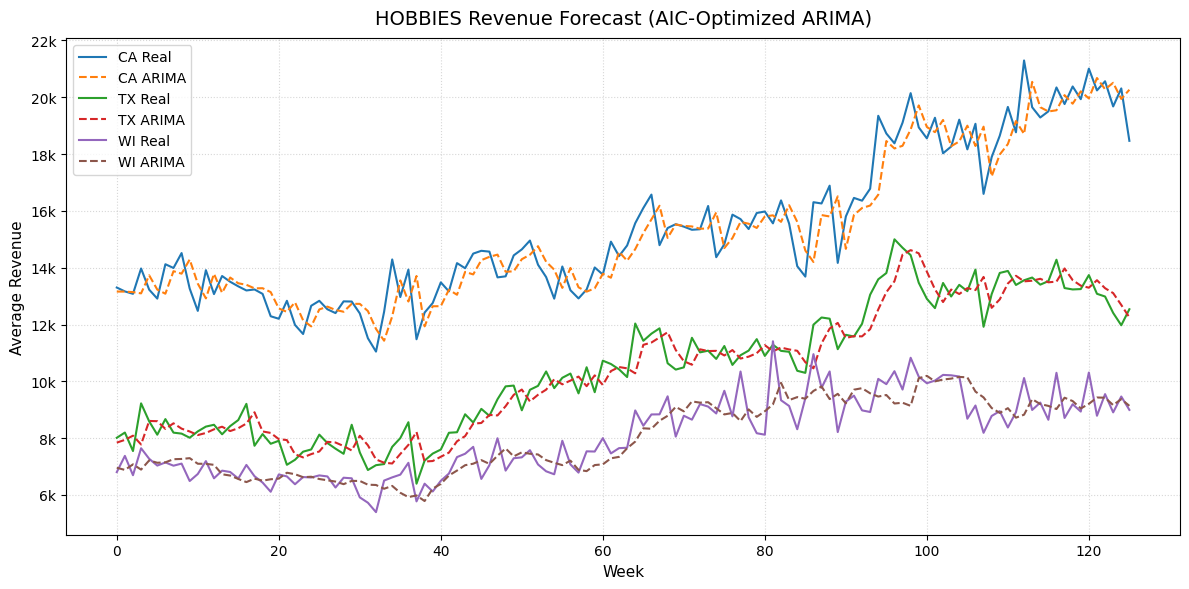

 CATEGORY: HOUSEHOLD 
HOUSEHOLD - CA (Selected Order: ARIMA(2, 1, 0))
MAE   : 1272.7781
RMSE  : 1569.4507
WRMSSE: 0.1012 (Weight: 0.1337)
MAPE  : 2.64%
------------------------------------------------------------
HOUSEHOLD - TX (Selected Order: ARIMA(1, 1, 2))
MAE   : 1019.7283
RMSE  : 1291.4081
WRMSSE: 0.0673 (Weight: 0.0845)
MAPE  : 3.43%
------------------------------------------------------------
HOUSEHOLD - WI (Selected Order: ARIMA(1, 1, 1))
MAE   : 1567.5230
RMSE  : 1948.5499
WRMSSE: 0.0724 (Weight: 0.0742)
MAPE  : 6.37%
------------------------------------------------------------


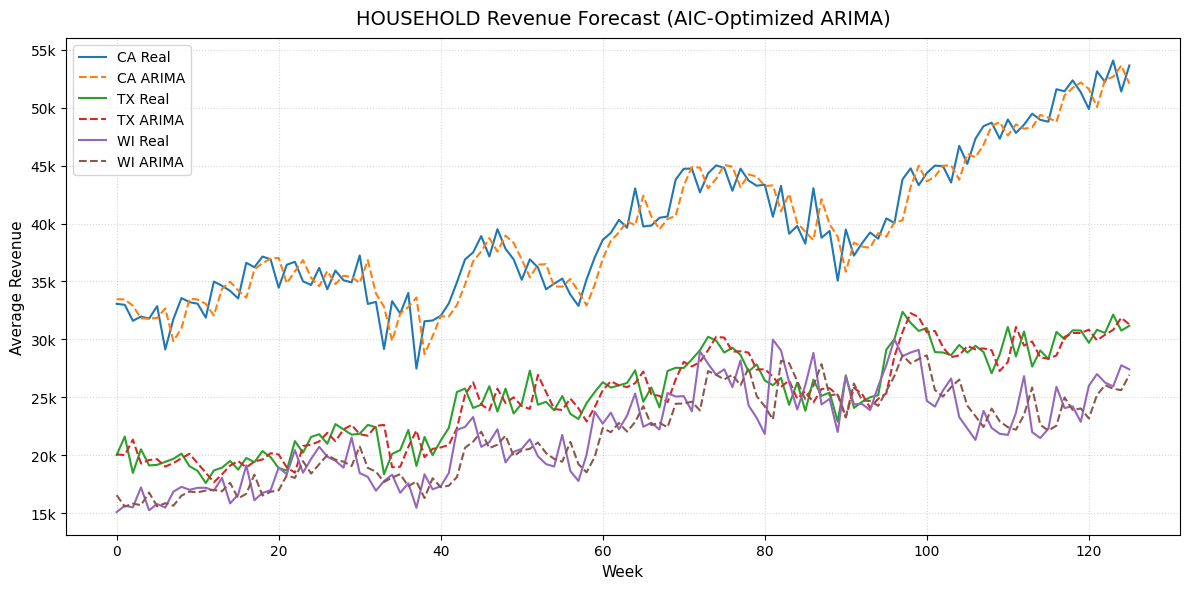

 CATEGORY: FOODS 
FOODS - CA (Selected Order: ARIMA(2, 1, 2))
MAE   : 3860.1002
RMSE  : 5240.1485
WRMSSE: 0.1927 (Weight: 0.2663)
MAPE  : 4.35%
------------------------------------------------------------
FOODS - TX (Selected Order: ARIMA(2, 1, 2))
MAE   : 2358.0893
RMSE  : 2900.4492
WRMSSE: 0.0898 (Weight: 0.1704)
MAPE  : 4.38%
------------------------------------------------------------
FOODS - WI (Selected Order: ARIMA(2, 1, 2))
MAE   : 3548.5503
RMSE  : 4314.6495
WRMSSE: 0.0879 (Weight: 0.1566)
MAPE  : 6.22%
------------------------------------------------------------


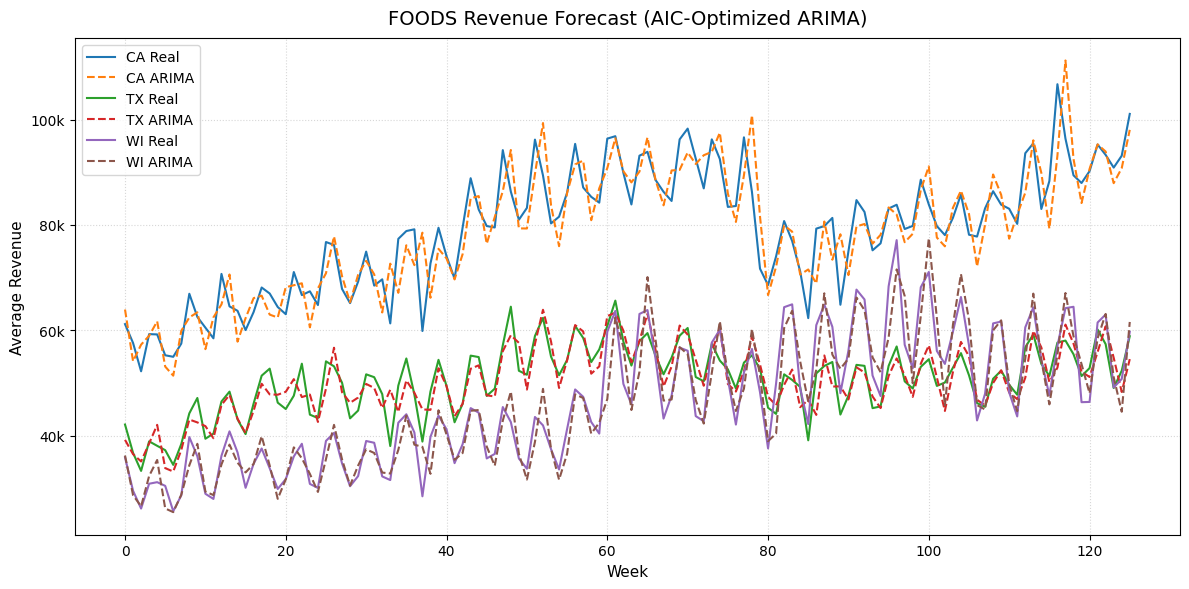

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suppress convergence warnings from non-matching grid search orders
warnings.filterwarnings("ignore")

# 1. Helper metrics matching M5 competition standards
def calculate_rmsse(train, test, forecast):
    denominator = np.mean(np.diff(train) ** 2)
    if denominator == 0:
        return 0
    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 2. Anti-Overfitting Hyperparameter Optimization Engine
def find_best_arima_order(train_series):
    """
    Finds the optimal (p, d, q) order using AIC to minimize overfitting risks.
    We cap orders at 2 to keep the model parsimonious and stable.
    """
    best_aic = float('inf')
    best_order = (1, 1, 1)  # Robust default fallback

    for p in [0, 1, 2]:
        for d in [0, 1]:
            for q in [0, 1, 2]:
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    results = model.fit()
                    if results.aic < best_aic:
                        best_aic = results.aic
                        best_order = (p, d, q)
                except:
                    continue
    return best_order

# --- Drop the incomplete final boundary week ---
last_week = weekly_avg['wm_yr_wk'].max()
weekly_avg_filtered = weekly_avg[weekly_avg['wm_yr_wk'] != last_week].copy()

categories = ['HOBBIES', 'HOUSEHOLD', 'FOODS']
states = ['CA', 'TX', 'WI']
test_size = 30
lookback = 10  # Aligns index with your RNN lookback window

# 3. Pre-calculate absolute revenue weights for WRMSEE scaling
revenue_weights = {}
grand_total_revenue = 0

for cat in categories:
    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ]
        if not df_subset.empty:
            total_rev = df_subset['revenue'].sum()
            revenue_weights[(cat, state)] = total_rev
            grand_total_revenue += total_rev

# Plot aesthetics
colors_real = {'CA': 'tab:blue', 'TX': 'tab:green', 'WI': 'tab:purple'}
colors_arima = {'CA': 'tab:orange', 'TX': 'tab:red', 'WI': 'tab:brown'}

# 4. Execution and Visual Alignment Loop
for cat in categories:
    plt.figure(figsize=(12, 6))
    print("=" * 60)
    print(f" CATEGORY: {cat} ")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered['cat_id'] == cat) &
            (weekly_avg_filtered['state_id'] == state)
        ].sort_values('wm_yr_wk')

        series = df_subset['revenue'].values
        if len(series) == 0:
            continue

        train = series[:-test_size]
        test = series[-test_size:]

        weight = revenue_weights.get((cat, state), 0) / grand_total_revenue

        # Find the optimal order on training data to prevent overfitting
        best_order = find_best_arima_order(train)

        # Walk-forward tracking using the optimal parsimonious order
        history = list(train)
        rolling_predictions = []

        for t in range(len(test)):
            model = ARIMA(history, order=best_order)
            model_fitted = model.fit()
            yhat = model_fitted.forecast(steps=1)[0]
            rolling_predictions.append(yhat)
            history.append(test[t])

        rolling_predictions = np.array(rolling_predictions)

        # Generate full baseline timeline matching the series shape
        initial_model = ARIMA(train, order=best_order).fit()
        in_sample = initial_model.fittedvalues
        full_pred = np.concatenate([in_sample, rolling_predictions])

        # Metrics computation
        mae = mean_absolute_error(test, rolling_predictions)
        rmse = np.sqrt(mean_squared_error(test, rolling_predictions))
        mape_val = calculate_mape(test, rolling_predictions)
        rmsse = calculate_rmsse(train, test, rolling_predictions)
        wrmsee = weight * rmsse

        # Printed metric summary
        print(f"{cat} - {state} (Selected Order: ARIMA{best_order})")
        print(f"MAE   : {mae:.4f}")
        print(f"RMSE  : {rmse:.4f}")
        print(f"WRMSSE: {wrmsee:.4f} (Weight: {weight:.4f})")
        print(f"MAPE  : {mape_val:.2f}%")
        print("-" * 60)

        # Truncate lookback elements to align perfectly with the RNN's data shape
        plot_real = series[lookback:]
        plot_pred = full_pred[lookback:]

        plt.plot(plot_real, label=f'{state} Real', color=colors_real[state], linestyle='-')
        plt.plot(plot_pred, label=f'{state} ARIMA', color=colors_arima[state], linestyle='--')

    # Chart polish
    plt.title(f"{cat} Revenue Forecast (AIC-Optimized ARIMA)", fontsize=14, pad=10)
    plt.xlabel("Week", fontsize=11)
    plt.ylabel("Average Revenue", fontsize=11)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

    plt.legend(loc='upper left', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Random Forest Revenue Forecast

This section implements a **Random Forest** regressor as a tree-ensemble alternative to ARIMA/LightGBM.

Like the LightGBM section, each week is converted into a tabular row containing:

- `lag_1 ... lag_10`: revenue from the previous 10 weeks
- `roll_mean_w` / `roll_std_w`: rolling mean/std over 3, 5, and 10-week windows
- `week_idx`: a simple trend index

**Key steps:**
1. **Feature engineering** — convert each category/state revenue series into a lagged tabular dataset.
2. **Hyperparameter search** — a global `RandomizedSearchCV` over Random Forest parameters (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`).
3. **Per-series fit** — refit a Random Forest with the best hyperparameters for each category/state pair.
4. **Walk-forward prediction** — predict one week at a time, then append the *actual* observed test value to history before building next week's features.
5. **Metrics** — MAE, RMSE, RMSSE, WRMSEE, and MAPE, computed with the same helper functions used elsewhere in the notebook.
6. **Visualization** — real vs. Random Forest-forecast weekly revenue per category and state.

CATEGORY : HOBBIES
HOBBIES-CA | Best RF params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 6}
MAE    : 642.7069
RMSE   : 917.6284
RMSSE  : 1.0339
WRMSEE : 0.0538 (Cumulative: 0.0538)
MAPE   : 3.33%
--------------------------------------------------
HOBBIES-TX | Best RF params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 6}
MAE    : 564.8395
RMSE   : 762.7747
RMSSE  : 1.2034
WRMSEE : 0.0421 (Cumulative: 0.0959)
MAPE   : 4.23%
--------------------------------------------------
HOBBIES-WI | Best RF params: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
MAE    : 516.5772
RMSE   : 663.6038
RMSSE  : 0.8584
WRMSEE : 0.0234 (Cumulative: 0.1193)
MAPE   : 5.55%
--------------------------------------------------


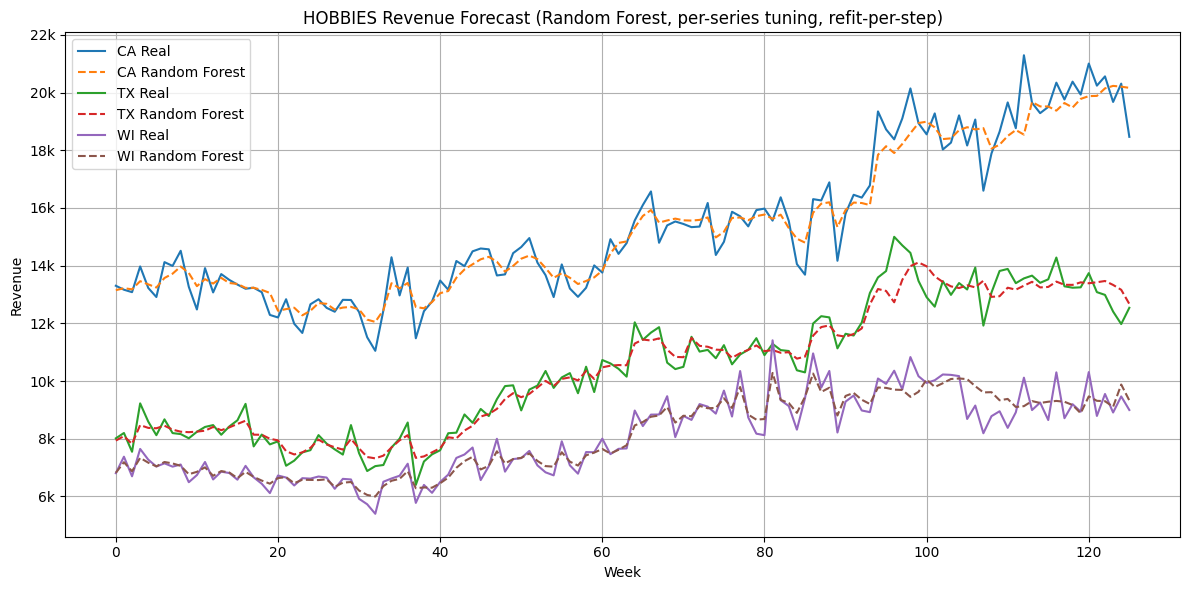

CATEGORY : HOUSEHOLD
HOUSEHOLD-CA | Best RF params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 6}
MAE    : 1521.1137
RMSE   : 1908.4357
RMSSE  : 0.9201
WRMSEE : 0.1230 (Cumulative: 0.2423)
MAPE   : 3.15%
--------------------------------------------------
HOUSEHOLD-TX | Best RF params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 6}
MAE    : 1348.1308
RMSE   : 1611.9322
RMSSE  : 0.9947
WRMSEE : 0.0840 (Cumulative: 0.3264)
MAPE   : 4.45%
--------------------------------------------------
HOUSEHOLD-WI | Best RF params: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
MAE    : 1785.3057
RMSE   : 2126.5352
RMSSE  : 1.0648
WRMSEE : 0.0790 (Cumulative: 0.4054)
MAPE   : 7.23%
--------------------------------------------------


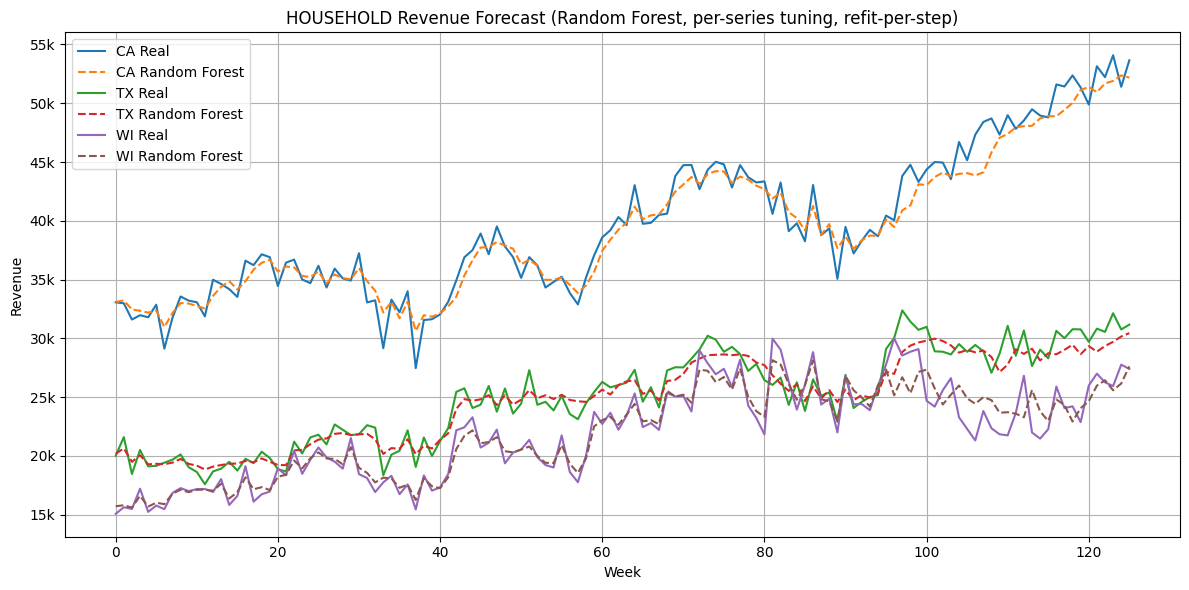

CATEGORY : FOODS
FOODS-CA | Best RF params: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
MAE    : 3949.9388
RMSE   : 5285.4890
RMSSE  : 0.7297
WRMSEE : 0.1943 (Cumulative: 0.5997)
MAPE   : 4.34%
--------------------------------------------------
FOODS-TX | Best RF params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
MAE    : 2650.1043
RMSE   : 3048.7508
RMSSE  : 0.5539
WRMSEE : 0.0944 (Cumulative: 0.6941)
MAPE   : 5.01%
--------------------------------------------------
FOODS-WI | Best RF params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
MAE    : 3791.3873
RMSE   : 4905.6137
RMSSE  : 0.6379
WRMSEE : 0.0999 (Cumulative: 0.7940)
MAPE   : 6.69%
--------------------------------------------------


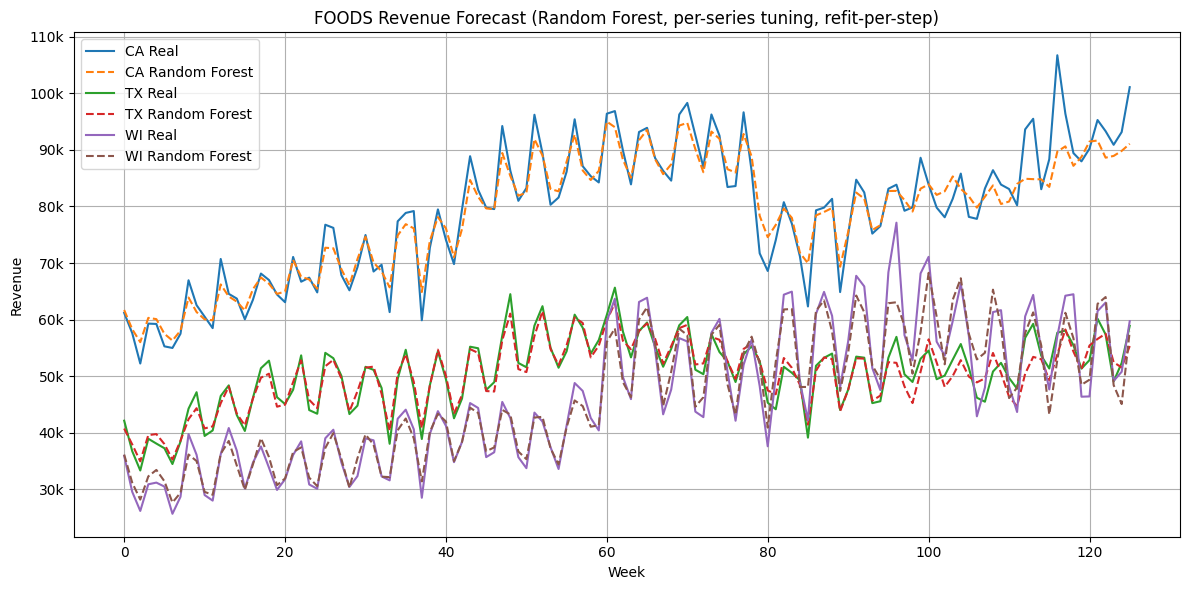


############################################################
Overall WRMSEE : 0.7940
############################################################


In [ ]:
import warnings
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

# ==========================================================
# METRICS (identical to the ARIMA / LightGBM sections)
# ==========================================================

def calculate_rmsse(train, test, forecast):
    train = np.array(train).flatten()
    test = np.array(test).flatten()
    forecast = np.array(forecast).flatten()

    denominator = np.mean(np.diff(train) ** 2)
    if denominator < 1e-8:
        return np.nan

    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

time_step = 10            # same lookback window used elsewhere in the notebook
n_lags = time_step        # number of lag features
roll_windows = [3, 5, 10]  # rolling mean/std windows (must be <= n_lags)


def build_feature_frame(series: np.ndarray, n_lags: int, roll_windows) -> pd.DataFrame:
    """
    Turns a 1D revenue series into a tabular feature set:
      lag_1 ... lag_n         -> previous n weeks
      roll_mean_w / roll_std_w -> rolling stats over lag_1..lag_w
      week_idx                 -> simple trend index
    Target column 'y' is the current week's revenue.
    """
    df = pd.DataFrame({"y": series})

    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    for w in roll_windows:
        lag_cols = [f"lag_{i}" for i in range(1, w + 1)]
        df[f"roll_mean_{w}"] = df[lag_cols].mean(axis=1)
        df[f"roll_std_{w}"] = df[lag_cols].std(axis=1)

    df["week_idx"] = np.arange(len(df))

    df = df.dropna().reset_index(drop=True)
    feature_cols = [c for c in df.columns if c != "y"]
    return df, feature_cols


# ==========================================================
# HYPERPARAMETER SEARCH SPACE
# (search is now run separately for EACH cat/state series, so every
#  series gets its own tuned model instead of one global model -
#  this puts RF on equal footing with the per-series ARIMA orders)
# ==========================================================

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 4, 6, 8, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0],
}

N_ITER = 15   # smaller than before since this now runs once PER series (9x total)
CV_FOLDS = 3

# ==========================================================
# FAIR WALK-FORWARD SETTING
# ARIMA refits ARIMA(history, order=best_order) at EVERY test step, so it
# always trains on all data available up to that point. To make RF an
# apples-to-apples comparison, we now also refit RF at every walk-forward
# step on the expanding history, using the best_params found once per
# series (the tree analogue of ARIMA's fixed best_order). This is much
# more expensive computationally (test_size refits per series instead of
# one), but it removes RF's "static model" advantage/disadvantage.
# ==========================================================

REFIT_EACH_STEP = True

# ==========================================================
# PARAMETERS FOR PER-SERIES PLOTS
# ==========================================================

colors_real = {"CA": "tab:blue", "TX": "tab:green", "WI": "tab:purple"}
colors_rf = {"CA": "tab:orange", "TX": "tab:red", "WI": "tab:brown"}

all_wrmsee_rf = []
best_params_per_series_rf = {}

# ==========================================================
# FORECASTING LOOP (tuning now happens INSIDE this loop, per series)
# ==========================================================

for cat in categories:
    plt.figure(figsize=(12, 6))

    print("=" * 60)
    print(f"CATEGORY : {cat}")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values
        if len(series) < n_lags + test_size + 1:
            continue

        # ==========================================
        # TRAIN / TEST SPLIT
        # ==========================================

        train_data = series[:-test_size]
        test_data = series[-test_size:]

        train_feat_df, feature_cols = build_feature_frame(train_data, n_lags, roll_windows)
        X_train = train_feat_df[feature_cols]
        y_train = train_feat_df["y"]

        # ==========================================
        # PER-SERIES HYPERPARAMETER SEARCH
        # (done ONCE on the training data only, exactly like ARIMA's
        #  best_order search - the walk-forward refits below reuse
        #  these best_params, they don't re-search every step)
        # ==========================================

        n_splits = min(CV_FOLDS, max(2, len(X_train) // 5))

        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        search = RandomizedSearchCV(
            base_model,
            param_distributions=param_dist,
            n_iter=N_ITER,
            scoring="neg_mean_squared_error",
            cv=n_splits,
            random_state=42,
            n_jobs=-1,
            verbose=0,
        )
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_params_per_series_rf[(cat, state)] = best_params

        print(f"{cat}-{state} | Best RF params: {best_params}")

        # ==========================================
        # WALK-FORWARD PREDICTION (model refit at EVERY step,
        # exactly like the ARIMA(history, order=best_order).fit()
        # call inside the ARIMA walk-forward loop)
        # ==========================================

        history = list(train_data)
        predictions = []

        for i in range(len(test_data)):
            hist_arr = np.array(history)

            if REFIT_EACH_STEP:
                hist_feat_df, _ = build_feature_frame(hist_arr, n_lags, roll_windows)
                X_hist = hist_feat_df[feature_cols]
                y_hist = hist_feat_df["y"]

                step_model = RandomForestRegressor(
                    **best_params, random_state=42, n_jobs=-1
                )
                step_model.fit(X_hist, y_hist)
            else:
                step_model = model

            feat_row = {}

            for lag in range(1, n_lags + 1):
                feat_row[f"lag_{lag}"] = hist_arr[-lag]

            for w in roll_windows:
                lag_vals = hist_arr[-w:]
                feat_row[f"roll_mean_{w}"] = np.mean(lag_vals)
                feat_row[f"roll_std_{w}"] = np.std(lag_vals)

            feat_row["week_idx"] = len(hist_arr)

            X_input = pd.DataFrame([feat_row])[feature_cols]
            pred = step_model.predict(X_input)[0]
            predictions.append(pred)

            # walk-forward: append the actual observed value, not the prediction
            history.append(test_data[i])

        predictions = np.array(predictions)
        actual = test_data

        # ==========================================
        # METRICS
        # ==========================================

        mae = mean_absolute_error(actual, predictions)
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mape = calculate_mape(actual, predictions)
        rmsse = calculate_rmsse(train_data, actual, predictions)

        weight = revenue_weights[(cat, state)] / grand_total_revenue
        wrmsee = weight * rmsse
        all_wrmsee_rf.append(wrmsee)

        print(f"MAE    : {mae:.4f}")
        print(f"RMSE   : {rmse:.4f}")
        print(f"RMSSE  : {rmsse:.4f}")
        print(f"WRMSEE : {wrmsee:.4f} (Cumulative: {np.nansum(all_wrmsee_rf):.4f})")
        print(f"MAPE   : {mape:.2f}%")
        print("-" * 50)

        # ==========================================
        # TRAIN FIT FOR PLOT
        # (a single model fit on train_data only, used purely to draw the
        #  in-sample line - same role as ARIMA's `initial_model` used for
        #  `in_sample = initial_model.fittedvalues`. It plays no part in
        #  the walk-forward predictions/metrics above.)
        # ==========================================

        initial_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        initial_model.fit(X_train, y_train)
        train_pred = initial_model.predict(X_train)

        full_pred = np.empty(len(series))
        full_pred[:] = np.nan
        full_pred[n_lags: n_lags + len(train_pred)] = train_pred
        full_pred[len(series) - len(predictions):] = predictions

        plt.plot(series[n_lags:], label=f"{state} Real", color=colors_real[state])
        plt.plot(full_pred[n_lags:], "--", label=f"{state} Random Forest", color=colors_rf[state])

    plt.title(f"{cat} Revenue Forecast (Random Forest, per-series tuning, refit-per-step)")
    plt.xlabel("Week")
    plt.ylabel("Revenue")

    ax = plt.gca()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    gc.collect()

# ==========================================================
# OVERALL WRMSEE
# ==========================================================

print("\n" + "#" * 60)
print(f"Overall WRMSEE : {np.nansum(all_wrmsee_rf):.4f}")
print("#" * 60)


### XGBoost Revenue Forecast

This section implements an **XGBoost** gradient-boosted-tree model, using the same tabular feature representation as the LightGBM and Random Forest sections.

Each week is converted into a row containing:

- `lag_1 ... lag_10`: revenue from the previous 10 weeks
- `roll_mean_w` / `roll_std_w`: rolling mean/std over 3, 5, and 10-week windows
- `week_idx`: a simple trend index

**Key steps:**
1. **Feature engineering** — convert each category/state revenue series into a lagged tabular dataset.
2. **Hyperparameter search** — a global `RandomizedSearchCV` over XGBoost parameters (`max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, etc.).
3. **Per-series fit** — refit XGBoost with the best hyperparameters for each category/state pair.
4. **Walk-forward prediction** — predict one week at a time, then append the *actual* observed test value to history before building next week's features.
5. **Metrics** — MAE, RMSE, RMSSE, WRMSEE, and MAPE, computed with the same helper functions used elsewhere in the notebook.
6. **Visualization** — real vs. XGBoost-forecast weekly revenue per category and state.

Install once if needed: `!pip install xgboost`

In [ ]:
!pip install xgboost

CATEGORY : HOBBIES
HOBBIES-CA | Best XGBoost params: {'subsample': 0.9, 'reg_lambda': 0.0, 'reg_alpha': 0.5, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
MAE    : 803.2062
RMSE   : 1056.2270
RMSSE  : 1.1901
WRMSEE : 0.0620 (Cumulative: 0.0620)
MAPE   : 4.18%
--------------------------------------------------
HOBBIES-TX | Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
MAE    : 574.0728
RMSE   : 730.3455
RMSSE  : 1.1523
WRMSEE : 0.0403 (Cumulative: 0.1022)
MAPE   : 4.33%
--------------------------------------------------
HOBBIES-WI | Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
MAE    : 573.6960
RMSE   : 753.3324
RMSSE  : 0.9745
WRMSEE : 0.0266 (Cumulativ

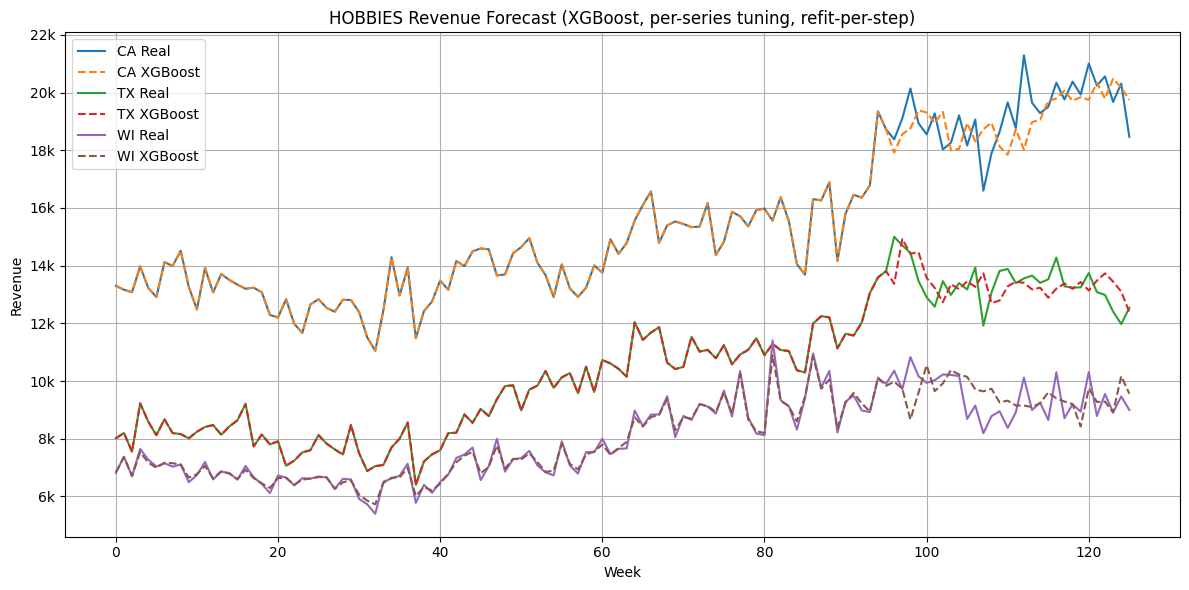

CATEGORY : HOUSEHOLD
HOUSEHOLD-CA | Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
MAE    : 1584.0884
RMSE   : 1962.1213
RMSSE  : 0.9460
WRMSEE : 0.1265 (Cumulative: 0.2553)
MAPE   : 3.27%
--------------------------------------------------
HOUSEHOLD-TX | Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MAE    : 1315.8430
RMSE   : 1575.9618
RMSSE  : 0.9725
WRMSEE : 0.0822 (Cumulative: 0.3375)
MAPE   : 4.39%
--------------------------------------------------
HOUSEHOLD-WI | Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
MAE    : 1670.4848
RMSE   : 2070.6570
RMSSE  : 1.0369
WRMSEE : 0.

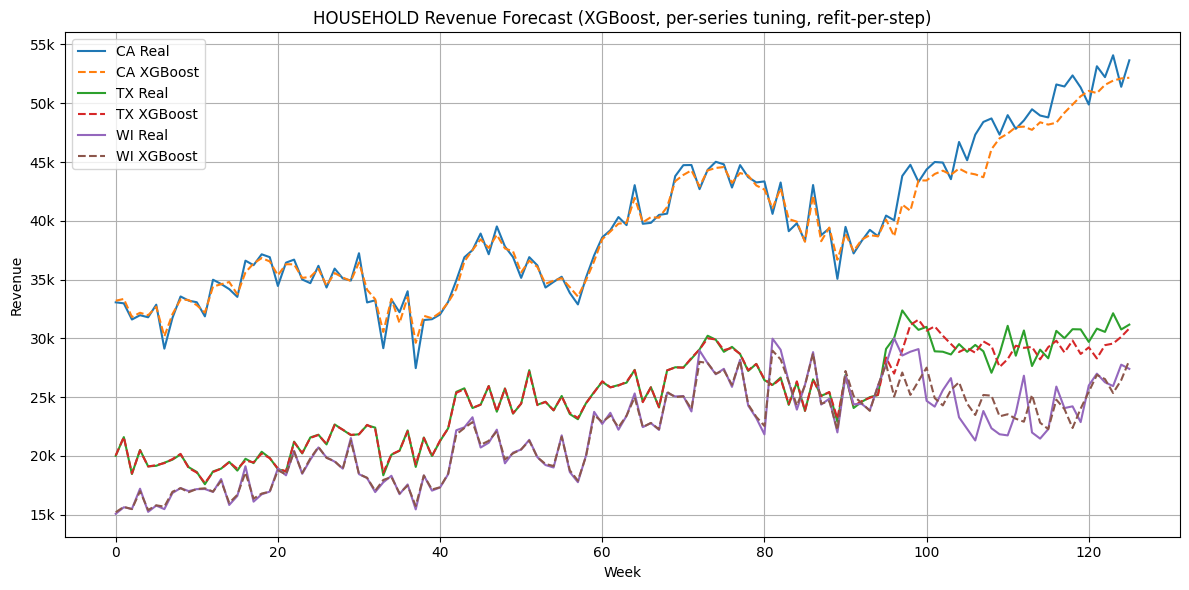

CATEGORY : FOODS
FOODS-CA | Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MAE    : 3656.6655
RMSE   : 4946.1451
RMSSE  : 0.6829
WRMSEE : 0.1819 (Cumulative: 0.5962)
MAPE   : 4.09%
--------------------------------------------------
FOODS-TX | Best XGBoost params: {'subsample': 0.9, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
MAE    : 2900.3762
RMSE   : 3215.9897
RMSSE  : 0.5842
WRMSEE : 0.0995 (Cumulative: 0.6958)
MAPE   : 5.47%
--------------------------------------------------
FOODS-WI | Best XGBoost params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
MAE    : 3875.5036
RMSE   : 5008.5529
RMSSE  : 0.6513
WRMSEE : 0.1020 (Cumulative

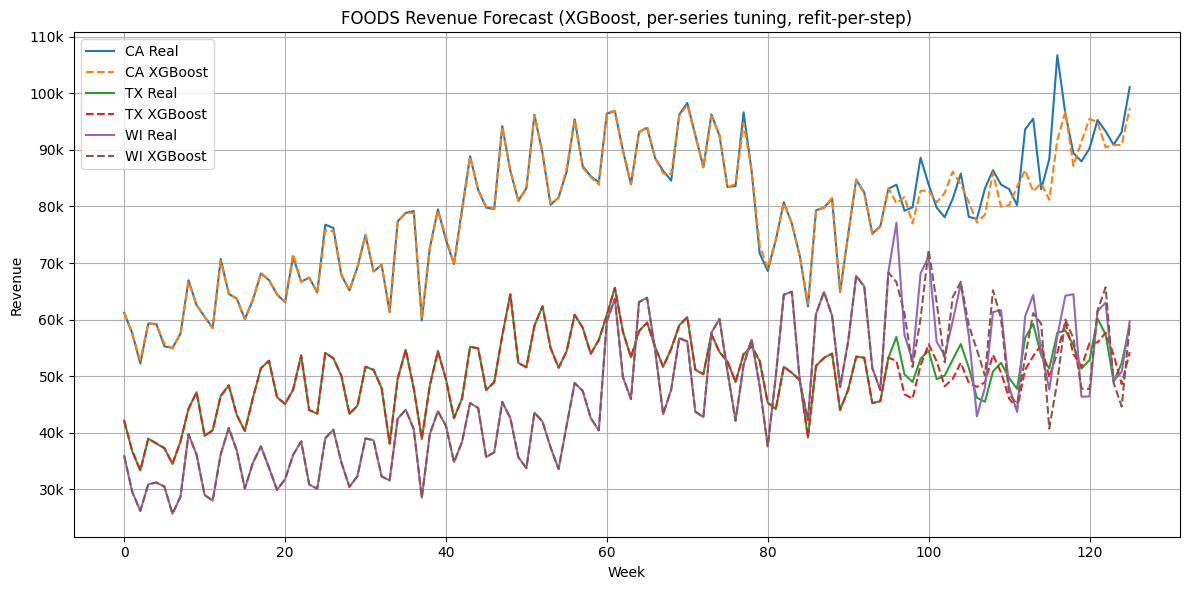


############################################################
Overall WRMSEE : 0.7978
############################################################


In [ ]:
import warnings
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

warnings.filterwarnings("ignore")

# ==========================================================
# METRICS (identical to the ARIMA / LightGBM / Random Forest sections)
# ==========================================================

def calculate_rmsse(train, test, forecast):
    train = np.array(train).flatten()
    test = np.array(test).flatten()
    forecast = np.array(forecast).flatten()

    denominator = np.mean(np.diff(train) ** 2)
    if denominator < 1e-8:
        return np.nan

    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

time_step = 10            # same lookback window used elsewhere in the notebook
n_lags = time_step        # number of lag features
roll_windows = [3, 5, 10]  # rolling mean/std windows (must be <= n_lags)


def build_feature_frame(series: np.ndarray, n_lags: int, roll_windows) -> pd.DataFrame:
    """
    Turns a 1D revenue series into a tabular feature set:
      lag_1 ... lag_n         -> previous n weeks
      roll_mean_w / roll_std_w -> rolling stats over lag_1..lag_w
      week_idx                 -> simple trend index
    Target column 'y' is the current week's revenue.
    """
    df = pd.DataFrame({"y": series})

    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    for w in roll_windows:
        lag_cols = [f"lag_{i}" for i in range(1, w + 1)]
        df[f"roll_mean_{w}"] = df[lag_cols].mean(axis=1)
        df[f"roll_std_{w}"] = df[lag_cols].std(axis=1)

    df["week_idx"] = np.arange(len(df))

    df = df.dropna().reset_index(drop=True)
    feature_cols = [c for c in df.columns if c != "y"]
    return df, feature_cols


# ==========================================================
# HYPERPARAMETER SEARCH SPACE
# (search is now run separately for EACH cat/state series, so every
#  series gets its own tuned model instead of one global model -
#  this puts XGBoost on equal footing with the per-series ARIMA orders)
# ==========================================================

param_dist = {
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 400, 600, 800],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 0.1, 0.5],
    "min_child_weight": [1, 3, 5],
}

N_ITER = 15   # smaller than before since this now runs once PER series (9x total)
CV_FOLDS = 3

# ==========================================================
# FAIR WALK-FORWARD SETTING
# ARIMA refits ARIMA(history, order=best_order) at EVERY test step, so it
# always trains on all data available up to that point. To make XGBoost an
# apples-to-apples comparison, we now also refit XGBoost at every
# walk-forward step on the expanding history, using the best_params found
# once per series (the tree analogue of ARIMA's fixed best_order). This is
# much more expensive computationally (test_size refits per series instead
# of one), but it removes XGBoost's "static model" advantage/disadvantage.
# ==========================================================

REFIT_EACH_STEP = True

# ==========================================================
# PARAMETERS FOR PER-SERIES PLOTS
# ==========================================================

colors_real = {"CA": "tab:blue", "TX": "tab:green", "WI": "tab:purple"}
colors_xgb = {"CA": "tab:orange", "TX": "tab:red", "WI": "tab:brown"}

all_wrmsee_xgb = []
best_params_per_series_xgb = {}

# ==========================================================
# FORECASTING LOOP (tuning now happens INSIDE this loop, per series)
# ==========================================================

for cat in categories:
    plt.figure(figsize=(12, 6))

    print("=" * 60)
    print(f"CATEGORY : {cat}")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values
        if len(series) < n_lags + test_size + 1:
            continue

        # ==========================================
        # TRAIN / TEST SPLIT
        # ==========================================

        train_data = series[:-test_size]
        test_data = series[-test_size:]

        train_feat_df, feature_cols = build_feature_frame(train_data, n_lags, roll_windows)
        X_train = train_feat_df[feature_cols]
        y_train = train_feat_df["y"]

        # ==========================================
        # PER-SERIES HYPERPARAMETER SEARCH
        # (done ONCE on the training data only, exactly like ARIMA's
        #  best_order search - the walk-forward refits below reuse
        #  these best_params, they don't re-search every step)
        # ==========================================

        n_splits = min(CV_FOLDS, max(2, len(X_train) // 5))

        base_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )
        search = RandomizedSearchCV(
            base_model,
            param_distributions=param_dist,
            n_iter=N_ITER,
            scoring="neg_mean_squared_error",
            cv=n_splits,
            random_state=42,
            n_jobs=-1,
            verbose=0,
        )
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_params_per_series_xgb[(cat, state)] = best_params

        print(f"{cat}-{state} | Best XGBoost params: {best_params}")

        # ==========================================
        # WALK-FORWARD PREDICTION (model refit at EVERY step,
        # exactly like the ARIMA(history, order=best_order).fit()
        # call inside the ARIMA walk-forward loop)
        # ==========================================

        history = list(train_data)
        predictions = []

        for i in range(len(test_data)):
            hist_arr = np.array(history)

            if REFIT_EACH_STEP:
                hist_feat_df, _ = build_feature_frame(hist_arr, n_lags, roll_windows)
                X_hist = hist_feat_df[feature_cols]
                y_hist = hist_feat_df["y"]

                step_model = xgb.XGBRegressor(
                    **best_params,
                    objective="reg:squarederror",
                    random_state=42,
                    n_jobs=-1,
                    verbosity=0,
                )
                step_model.fit(X_hist, y_hist)
            else:
                step_model = model

            feat_row = {}

            for lag in range(1, n_lags + 1):
                feat_row[f"lag_{lag}"] = hist_arr[-lag]

            for w in roll_windows:
                lag_vals = hist_arr[-w:]
                feat_row[f"roll_mean_{w}"] = np.mean(lag_vals)
                feat_row[f"roll_std_{w}"] = np.std(lag_vals)

            feat_row["week_idx"] = len(hist_arr)

            X_input = pd.DataFrame([feat_row])[feature_cols]
            pred = step_model.predict(X_input)[0]
            predictions.append(pred)

            # walk-forward: append the actual observed value, not the prediction
            history.append(test_data[i])

        predictions = np.array(predictions)
        actual = test_data

        # ==========================================
        # METRICS
        # ==========================================

        mae = mean_absolute_error(actual, predictions)
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mape = calculate_mape(actual, predictions)
        rmsse = calculate_rmsse(train_data, actual, predictions)

        weight = revenue_weights[(cat, state)] / grand_total_revenue
        wrmsee = weight * rmsse
        all_wrmsee_xgb.append(wrmsee)

        print(f"MAE    : {mae:.4f}")
        print(f"RMSE   : {rmse:.4f}")
        print(f"RMSSE  : {rmsse:.4f}")
        print(f"WRMSEE : {wrmsee:.4f} (Cumulative: {np.nansum(all_wrmsee_xgb):.4f})")
        print(f"MAPE   : {mape:.2f}%")
        print("-" * 50)

        # ==========================================
        # TRAIN FIT FOR PLOT
        # (a single model fit on train_data only, used purely to draw the
        #  in-sample line - same role as ARIMA's `initial_model` used for
        #  `in_sample = initial_model.fittedvalues`. It plays no part in
        #  the walk-forward predictions/metrics above.)
        # ==========================================

        initial_model = xgb.XGBRegressor(
            **best_params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )
        initial_model.fit(X_train, y_train)
        train_pred = initial_model.predict(X_train)

        full_pred = np.empty(len(series))
        full_pred[:] = np.nan
        full_pred[n_lags: n_lags + len(train_pred)] = train_pred
        full_pred[len(series) - len(predictions):] = predictions

        plt.plot(series[n_lags:], label=f"{state} Real", color=colors_real[state])
        plt.plot(full_pred[n_lags:], "--", label=f"{state} XGBoost", color=colors_xgb[state])

    plt.title(f"{cat} Revenue Forecast (XGBoost, per-series tuning, refit-per-step)")
    plt.xlabel("Week")
    plt.ylabel("Revenue")

    ax = plt.gca()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    gc.collect()

# ==========================================================
# OVERALL WRMSEE
# ==========================================================

print("\n" + "#" * 60)
print(f"Overall WRMSEE : {np.nansum(all_wrmsee_xgb):.4f}")
print("#" * 60)


### LightGBM Revenue Forecast

This section implements a **LightGBM** gradient-boosted-tree model as an alternative to the ARIMA/LSTM/CNN forecasts above.

Unlike the CNN/LSTM models, LightGBM operates on **tabular features** rather than raw sequences, so each week is converted into a row containing:

- `lag_1 ... lag_10`: revenue from the previous 10 weeks
- `roll_mean_w` / `roll_std_w`: rolling mean/std over 3, 5, and 10-week windows
- `week_idx`: a simple trend index

**Key steps:**
1. **Feature engineering** — convert each category/state revenue series into a lagged tabular dataset.
2. **Hyperparameter search** — a global `RandomizedSearchCV` over LightGBM parameters (num_leaves, depth, learning rate, etc.), analogous to the Keras Tuner step used for the CNN.
3. **Per-series fit** — refit LightGBM with the best hyperparameters for each category/state pair.
4. **Walk-forward prediction** — predict one week at a time, then append the *actual* observed test value to history before building next week's features (same strategy as the CNN/LSTM sections).
5. **Metrics** — MAE, RMSE, RMSSE, WRMSEE, and MAPE, computed with the same helper functions used elsewhere in the notebook.
6. **Visualization** — real vs. LightGBM-forecast weekly revenue per category and state.

Install once if needed: `!pip install lightgbm`

In [ ]:
!pip install lightgbm

CATEGORY : HOBBIES
HOBBIES-CA | Best LightGBM params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 400, 'min_child_samples': 30, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
MAE    : 1498.3712
RMSE   : 1736.7301
RMSSE  : 1.9568
WRMSEE : 0.1019 (Cumulative: 0.1019)
MAPE   : 7.70%
--------------------------------------------------
HOBBIES-TX | Best LightGBM params: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 600, 'min_child_samples': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
MAE    : 651.1370
RMSE   : 808.0141
RMSSE  : 1.2748
WRMSEE : 0.0446 (Cumulative: 0.1465)
MAPE   : 4.88%
--------------------------------------------------
HOBBIES-WI | Best LightGBM params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 30, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
MAE    : 662.

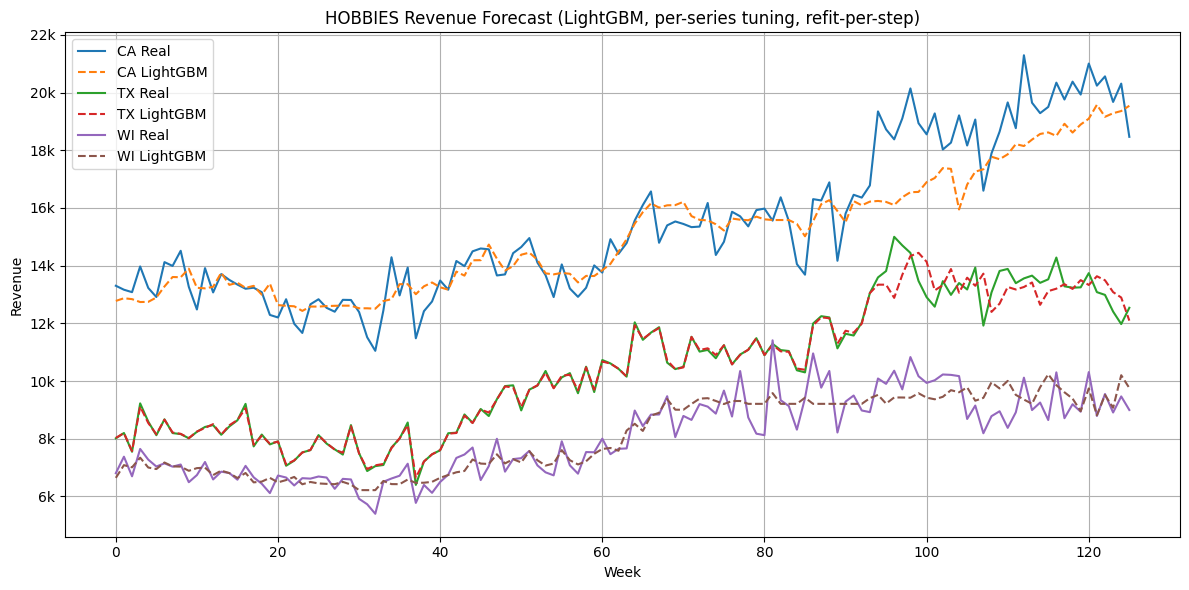

CATEGORY : HOUSEHOLD
HOUSEHOLD-CA | Best LightGBM params: {'subsample': 0.9, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE    : 1367.1609
RMSE   : 1718.8686
RMSSE  : 0.8287
WRMSEE : 0.1108 (Cumulative: 0.2853)
MAPE   : 2.83%
--------------------------------------------------
HOUSEHOLD-TX | Best LightGBM params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 600, 'min_child_samples': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MAE    : 1297.4197
RMSE   : 1622.1484
RMSSE  : 1.0010
WRMSEE : 0.0846 (Cumulative: 0.3698)
MAPE   : 4.31%
--------------------------------------------------
HOUSEHOLD-WI | Best LightGBM params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'num_leaves': 127, 'n_estimators': 600, 'min_child_samples': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
MAE   

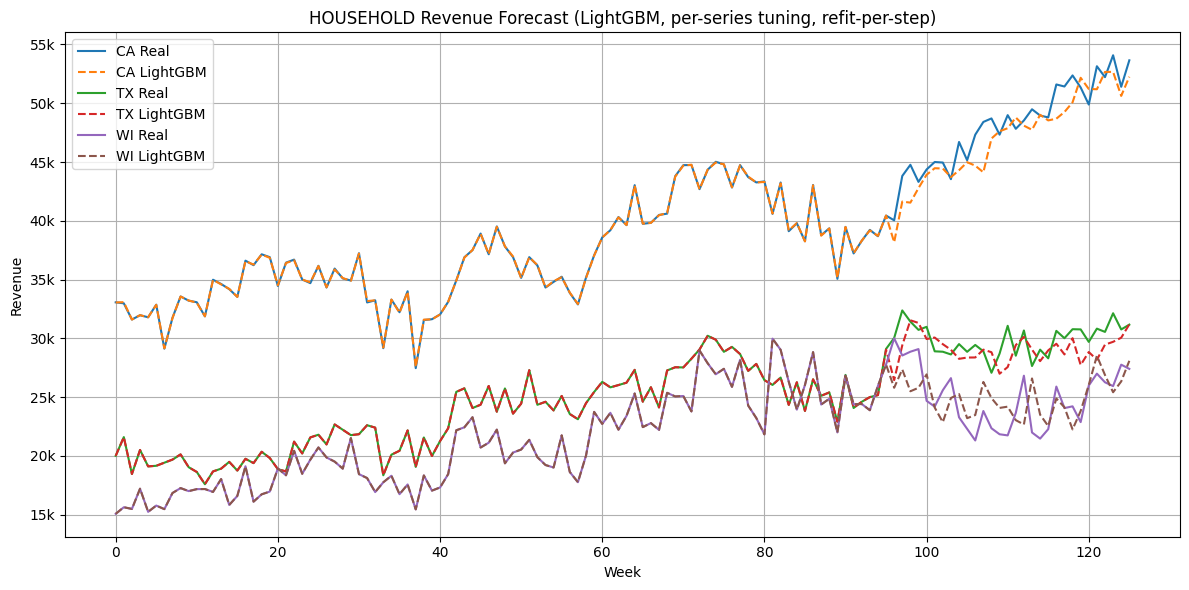

CATEGORY : FOODS
FOODS-CA | Best LightGBM params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'num_leaves': 127, 'n_estimators': 600, 'min_child_samples': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
MAE    : 3797.9786
RMSE   : 5011.4248
RMSSE  : 0.6919
WRMSEE : 0.1843 (Cumulative: 0.6354)
MAPE   : 4.26%
--------------------------------------------------
FOODS-TX | Best LightGBM params: {'subsample': 0.9, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE    : 2627.6097
RMSE   : 3159.9629
RMSSE  : 0.5741
WRMSEE : 0.0978 (Cumulative: 0.7332)
MAPE   : 5.01%
--------------------------------------------------
FOODS-WI | Best LightGBM params: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 600, 'min_child_samples': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
MAE    : 4729.3979
RMS

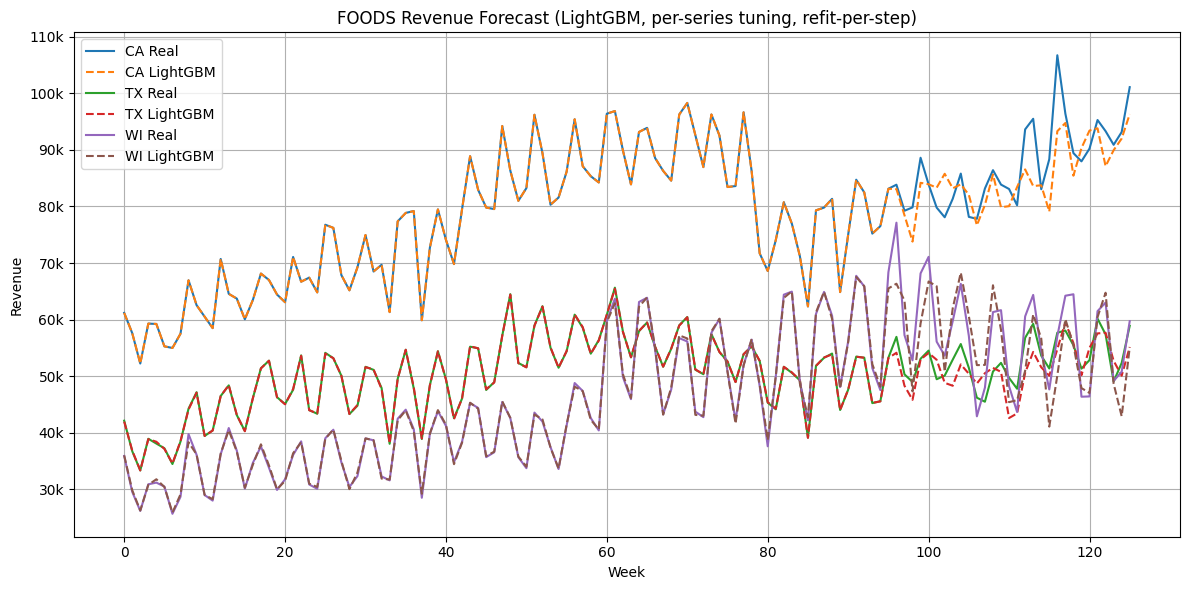


############################################################
Overall WRMSEE : 0.8472
############################################################


In [ ]:
import warnings
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

warnings.filterwarnings("ignore")

# ==========================================================
# METRICS (identical to the ARIMA / CNN sections)
# ==========================================================

def calculate_rmsse(train, test, forecast):
    train = np.array(train).flatten()
    test = np.array(test).flatten()
    forecast = np.array(forecast).flatten()

    denominator = np.mean(np.diff(train) ** 2)
    if denominator < 1e-8:
        return np.nan

    numerator = np.mean((test - forecast) ** 2)
    return np.sqrt(numerator / denominator)


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

time_step = 10          # same lookback window used for the CNN/LSTM models
n_lags = time_step       # number of lag features
roll_windows = [3, 5, 10]  # rolling mean/std windows (must be <= n_lags)


def build_feature_frame(series: np.ndarray, n_lags: int, roll_windows) -> pd.DataFrame:
    """
    Turns a 1D revenue series into a tabular feature set:
      lag_1 ... lag_n         -> previous n weeks
      roll_mean_w / roll_std_w -> rolling stats over lag_1..lag_w
      week_idx                 -> simple trend index
    Target column 'y' is the current week's revenue.
    """
    df = pd.DataFrame({"y": series})

    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    for w in roll_windows:
        lag_cols = [f"lag_{i}" for i in range(1, w + 1)]
        df[f"roll_mean_{w}"] = df[lag_cols].mean(axis=1)
        df[f"roll_std_{w}"] = df[lag_cols].std(axis=1)

    df["week_idx"] = np.arange(len(df))

    df = df.dropna().reset_index(drop=True)
    feature_cols = [c for c in df.columns if c != "y"]
    return df, feature_cols


# ==========================================================
# HYPERPARAMETER SEARCH SPACE
# (search is now run separately for EACH cat/state series, so every
#  series gets its own tuned model instead of one global model -
#  this puts LightGBM on equal footing with the per-series ARIMA orders)
# ==========================================================

param_dist = {
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 400, 600, 800],
    "min_child_samples": [5, 10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 0.1, 0.5],
}

N_ITER = 15   # smaller than before since this now runs once PER series (9x total)
CV_FOLDS = 3

# ==========================================================
# FAIR WALK-FORWARD SETTING
# ARIMA refits ARIMA(history, order=best_order) at EVERY test step, so it
# always trains on all data available up to that point. To make LightGBM an
# apples-to-apples comparison, we now also refit LightGBM at every
# walk-forward step on the expanding history, using the best_params found
# once per series (the tree analogue of ARIMA's fixed best_order). This is
# much more expensive computationally (test_size refits per series instead
# of one), but it removes LightGBM's "static model" advantage/disadvantage.
# ==========================================================

REFIT_EACH_STEP = True

# ==========================================================
# PARAMETERS FOR PER-SERIES PLOTS
# ==========================================================

colors_real = {"CA": "tab:blue", "TX": "tab:green", "WI": "tab:purple"}
colors_lgbm = {"CA": "tab:orange", "TX": "tab:red", "WI": "tab:brown"}

all_wrmsee_lgbm = []
best_params_per_series_lgbm = {}

# ==========================================================
# FORECASTING LOOP (tuning now happens INSIDE this loop, per series)
# ==========================================================

for cat in categories:
    plt.figure(figsize=(12, 6))

    print("=" * 60)
    print(f"CATEGORY : {cat}")
    print("=" * 60)

    for state in states:
        df_subset = weekly_avg_filtered[
            (weekly_avg_filtered["cat_id"] == cat) &
            (weekly_avg_filtered["state_id"] == state)
        ].sort_values("wm_yr_wk")

        series = df_subset["revenue"].values
        if len(series) < n_lags + test_size + 1:
            continue

        # ==========================================
        # TRAIN / TEST SPLIT
        # ==========================================

        train_data = series[:-test_size]
        test_data = series[-test_size:]

        train_feat_df, feature_cols = build_feature_frame(train_data, n_lags, roll_windows)
        X_train = train_feat_df[feature_cols]
        y_train = train_feat_df["y"]

        # ==========================================
        # PER-SERIES HYPERPARAMETER SEARCH
        # (done ONCE on the training data only, exactly like ARIMA's
        #  best_order search - the walk-forward refits below reuse
        #  these best_params, they don't re-search every step)
        # ==========================================

        n_splits = min(CV_FOLDS, max(2, len(X_train) // 5))

        base_model = lgb.LGBMRegressor(objective="regression", random_state=42, verbosity=-1)
        search = RandomizedSearchCV(
            base_model,
            param_distributions=param_dist,
            n_iter=N_ITER,
            scoring="neg_mean_squared_error",
            cv=n_splits,
            random_state=42,
            n_jobs=-1,
            verbose=0,
        )
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_params_per_series_lgbm[(cat, state)] = best_params

        print(f"{cat}-{state} | Best LightGBM params: {best_params}")

        # ==========================================
        # WALK-FORWARD PREDICTION (model refit at EVERY step,
        # exactly like the ARIMA(history, order=best_order).fit()
        # call inside the ARIMA walk-forward loop)
        # ==========================================

        history = list(train_data)
        predictions = []

        for i in range(len(test_data)):
            hist_arr = np.array(history)

            if REFIT_EACH_STEP:
                hist_feat_df, _ = build_feature_frame(hist_arr, n_lags, roll_windows)
                X_hist = hist_feat_df[feature_cols]
                y_hist = hist_feat_df["y"]

                step_model = lgb.LGBMRegressor(
                    **best_params, objective="regression", random_state=42, verbosity=-1
                )
                step_model.fit(X_hist, y_hist)
            else:
                step_model = model

            feat_row = {}

            for lag in range(1, n_lags + 1):
                feat_row[f"lag_{lag}"] = hist_arr[-lag]

            for w in roll_windows:
                lag_vals = hist_arr[-w:]
                feat_row[f"roll_mean_{w}"] = np.mean(lag_vals)
                feat_row[f"roll_std_{w}"] = np.std(lag_vals)

            feat_row["week_idx"] = len(hist_arr)

            X_input = pd.DataFrame([feat_row])[feature_cols]
            pred = step_model.predict(X_input)[0]
            predictions.append(pred)

            # walk-forward: append the actual observed value, not the prediction
            history.append(test_data[i])

        predictions = np.array(predictions)
        actual = test_data

        # ==========================================
        # METRICS
        # ==========================================

        mae = mean_absolute_error(actual, predictions)
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mape = calculate_mape(actual, predictions)
        rmsse = calculate_rmsse(train_data, actual, predictions)

        weight = revenue_weights[(cat, state)] / grand_total_revenue
        wrmsee = weight * rmsse
        all_wrmsee_lgbm.append(wrmsee)

        print(f"MAE    : {mae:.4f}")
        print(f"RMSE   : {rmse:.4f}")
        print(f"RMSSE  : {rmsse:.4f}")
        print(f"WRMSEE : {wrmsee:.4f} (Cumulative: {np.nansum(all_wrmsee_lgbm):.4f})")
        print(f"MAPE   : {mape:.2f}%")
        print("-" * 50)

        # ==========================================
        # TRAIN FIT FOR PLOT
        # (a single model fit on train_data only, used purely to draw the
        #  in-sample line - same role as ARIMA's `initial_model` used for
        #  `in_sample = initial_model.fittedvalues`. It plays no part in
        #  the walk-forward predictions/metrics above.)
        # ==========================================

        initial_model = lgb.LGBMRegressor(
            **best_params, objective="regression", random_state=42, verbosity=-1
        )
        initial_model.fit(X_train, y_train)
        train_pred = initial_model.predict(X_train)

        full_pred = np.empty(len(series))
        full_pred[:] = np.nan
        full_pred[n_lags: n_lags + len(train_pred)] = train_pred
        full_pred[len(series) - len(predictions):] = predictions

        plt.plot(series[n_lags:], label=f"{state} Real", color=colors_real[state])
        plt.plot(full_pred[n_lags:], "--", label=f"{state} LightGBM", color=colors_lgbm[state])

    plt.title(f"{cat} Revenue Forecast (LightGBM, per-series tuning, refit-per-step)")
    plt.xlabel("Week")
    plt.ylabel("Revenue")

    ax = plt.gca()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    gc.collect()

# ==========================================================
# OVERALL WRMSEE
# ==========================================================

print("\n" + "#" * 60)
print(f"Overall WRMSEE : {np.nansum(all_wrmsee_lgbm):.4f}")
print("#" * 60)
